# GBMEncoder 使用示例

基于 XGBoost、LightGBM、CatBoost 的梯度提升树编码器，支持 GBDT + LR 等组合模型。

## 功能特性
- 支持多种输出类型: leaves, onehot, probability, embedding
- 支持三种主流GBM: XGBoost, LightGBM, CatBoost
- 原生支持类别特征（CatBoost）
- 可与 sklearn Pipeline 无缝集成

In [1]:
# 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.pipeline import Pipeline

# 导入 hscredit 的 GBMEncoder
import sys
sys.path.insert(0, '/Users/xiaoxi/CodeBuddy/hscredit/hscredit')
from hscredit.core.encoders import GBMEncoder

print("✓ 所有库导入成功")

✓ 所有库导入成功


## 1. 生成示例数据

In [2]:
def generate_sample_data(n_samples=10000, n_features=20, random_state=42):
    """生成包含数值和类别特征的示例数据."""
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=15,
        n_redundant=5,
        n_classes=2,
        random_state=random_state
    )
    
    X_df = pd.DataFrame(X, columns=[f'feat_{i}' for i in range(n_features)])
    
    # 添加类别特征
    X_df['cat_1'] = np.random.choice(['A', 'B', 'C', 'D'], size=n_samples)
    X_df['cat_2'] = np.random.choice(['X', 'Y', 'Z'], size=n_samples)
    
    return X_df, pd.Series(y, name='target')

# 生成数据
X, y = generate_sample_data(n_samples=10000)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"训练集大小: {len(X_train)}")
print(f"测试集大小: {len(X_test)}")
print(f"\n特征列表: {list(X.columns)}")
print(f"\n数据预览:")
X_train.head()

训练集大小: 8000
测试集大小: 2000

特征列表: ['feat_0', 'feat_1', 'feat_2', 'feat_3', 'feat_4', 'feat_5', 'feat_6', 'feat_7', 'feat_8', 'feat_9', 'feat_10', 'feat_11', 'feat_12', 'feat_13', 'feat_14', 'feat_15', 'feat_16', 'feat_17', 'feat_18', 'feat_19', 'cat_1', 'cat_2']

数据预览:


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_12,feat_13,feat_14,feat_15,feat_16,feat_17,feat_18,feat_19,cat_1,cat_2
9254,-1.932546,1.083850,-2.473768,-0.151583,0.585492,0.021160,3.181755,-0.393872,8.365130,5.104480,...,0.516888,1.287722,-0.836873,-6.922010,1.574602,-0.548375,4.916928,-2.039878,B,Y
1561,-2.834493,0.650949,-0.720071,-2.280859,5.510135,-1.213197,3.498631,0.413433,-2.618989,-1.981399,...,2.086649,1.296812,-2.298527,0.728999,-2.835093,-2.479487,-0.737065,-4.986793,C,X
1670,-0.955119,1.469451,3.312042,-8.346075,-3.312231,-1.400914,-4.135418,2.358446,-2.945977,-0.117599,...,3.022030,2.774295,-0.570501,-0.049389,-0.244215,-3.638676,-1.392192,-3.909594,A,Y
6087,-1.254031,1.412798,3.616956,1.119862,2.171062,1.466159,-4.319357,1.118976,-2.838671,7.376649,...,-4.012532,-1.406500,4.693534,1.628795,11.035640,-0.578209,4.176530,4.496910,D,Z
6669,-2.233549,1.108942,-12.537013,14.601435,-0.587908,0.074039,7.479747,-1.243120,9.945749,-5.620564,...,-3.425178,-2.652139,1.302250,-5.842387,-4.600742,1.216915,7.903714,7.668796,D,Z


## 2. 示例: XGBoost + 叶子节点特征

In [3]:
# 创建GBM编码器
encoder = GBMEncoder(
    model_type='xgboost',
    n_estimators=30,
    max_depth=3,
    output_type='leaves',
    drop_origin=False,  # 保留原始特征
    random_state=42
)

# 拟合并转换
X_train_encoded = encoder.fit_transform(X_train, y_train)
X_test_encoded = encoder.transform(X_test)

print(f"原始特征数: {X_train.shape[1]}")
print(f"编码后特征数: {X_train_encoded.shape[1]}")
print(f"新增树特征: {encoder.n_trees_}棵树的叶子节点")
print(f"\n新增特征示例: {encoder.feature_names_[:5]}...")

原始特征数: 22
编码后特征数: 52
新增树特征: 30棵树的叶子节点

新增特征示例: ['gbm_tree_0', 'gbm_tree_1', 'gbm_tree_2', 'gbm_tree_3', 'gbm_tree_4']...


In [4]:
# 查看特征重要性
importance = encoder.get_feature_importance()
print("\nTop 10 重要特征:")
importance.head(10)


Top 10 重要特征:


,feature,importance
4,feat_4,0.128203
5,feat_5,0.088557
1,feat_1,0.081161
8,feat_8,0.077156
11,feat_11,0.075130
0,feat_0,0.061423
15,feat_15,0.055005
17,feat_17,0.051954
14,feat_14,0.048249
3,feat_3,0.045760


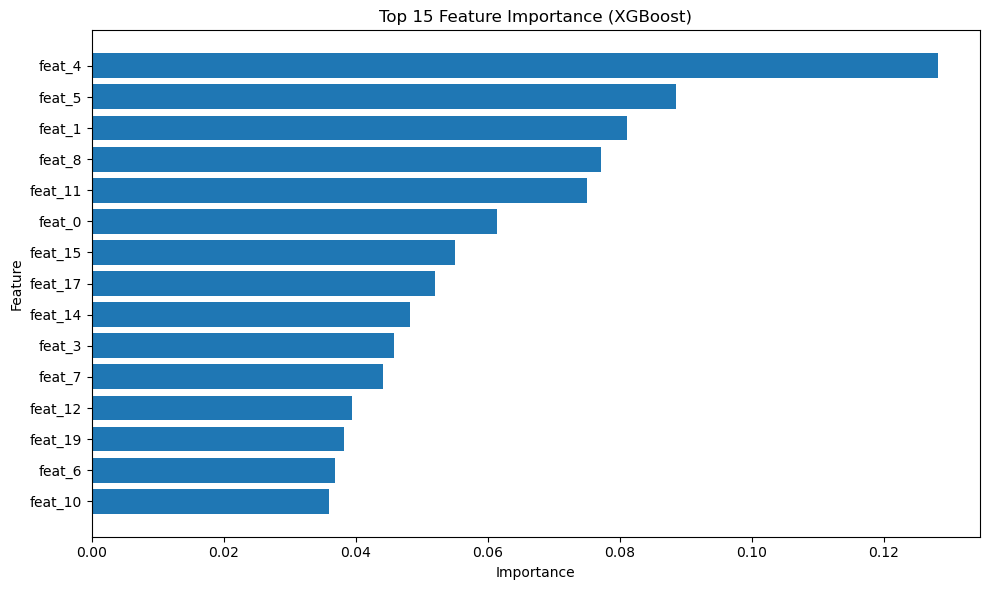

In [5]:
# 可视化特征重要性
plt.figure(figsize=(10, 6))
top_features = importance.head(15)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importance (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 3. 示例: XGBoost + LR 组合 (GBDT + LR)

In [6]:
# 方案1: 使用Pipeline
print("--- 方案1: 使用Pipeline ---")
pipeline = Pipeline([
    ('gbm_encoder', GBMEncoder(
        model_type='xgboost',
        n_estimators=50,
        max_depth=4,
        output_type='leaves',
        drop_origin=True,  # 删除原始特征，只用叶子节点
        random_state=42
    )),
    ('lr', LogisticRegression(max_iter=1000, C=0.5))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)
acc = accuracy_score(y_test, (y_pred > 0.5).astype(int))

print(f"XGBoost+LR AUC: {auc:.4f}")
print(f"XGBoost+LR Accuracy: {acc:.4f}")

--- 方案1: 使用Pipeline ---
XGBoost+LR AUC: 0.8986
XGBoost+LR Accuracy: 0.8200


In [7]:
# 方案2: 手动分步 (使用onehot编码)
print("\n--- 方案2: 手动分步 (onehot编码) ---")
encoder2 = GBMEncoder(
    model_type='xgboost',
    n_estimators=50,
    max_depth=4,
    output_type='onehot',  # 使用独热编码
    drop_origin=True,
    random_state=42
)

X_train_leaves = encoder2.fit_transform(X_train, y_train)
X_test_leaves = encoder2.transform(X_test)

print(f"叶子节点独热编码后维度: {X_train_leaves.shape[1]}")

# 训练LR
lr = LogisticRegression(max_iter=1000, C=0.5)
lr.fit(X_train_leaves, y_train)

y_pred2 = lr.predict_proba(X_test_leaves)[:, 1]
auc2 = roc_auc_score(y_test, y_pred2)
acc2 = accuracy_score(y_test, (y_pred2 > 0.5).astype(int))

print(f"XGBoost+LR (onehot) AUC: {auc2:.4f}")
print(f"XGBoost+LR (onehot) Accuracy: {acc2:.4f}")


--- 方案2: 手动分步 (onehot编码) ---
叶子节点独热编码后维度: 630
XGBoost+LR (onehot) AUC: 0.9794
XGBoost+LR (onehot) Accuracy: 0.9280


## 4. 示例: LightGBM + LR

In [8]:
# LightGBM + LR
encoder_lgb = GBMEncoder(
    model_type='lightgbm',
    n_estimators=40,
    max_depth=4,
    output_type='leaves',
    drop_origin=True,
    random_state=42
)

X_train_lgb = encoder_lgb.fit_transform(X_train, y_train)
X_test_lgb = encoder_lgb.transform(X_test)

lr_lgb = LogisticRegression(max_iter=1000)
lr_lgb.fit(X_train_lgb, y_train)

y_pred_lgb = lr_lgb.predict_proba(X_test_lgb)[:, 1]
auc_lgb = roc_auc_score(y_test, y_pred_lgb)

print(f"LightGBM+LR AUC: {auc_lgb:.4f}")

# 对比纯LightGBM
try:
    import lightgbm as lgb
    lgb_model = lgb.LGBMClassifier(n_estimators=40, max_depth=4, random_state=42, verbose=-1)
    lgb_model.fit(X_train.drop(columns=['cat_1', 'cat_2']), y_train)
    y_pred_pure_lgb = lgb_model.predict_proba(X_test.drop(columns=['cat_1', 'cat_2']))[:, 1]
    auc_pure_lgb = roc_auc_score(y_test, y_pred_pure_lgb)
    print(f"纯LightGBM AUC: {auc_pure_lgb:.4f}")
except ImportError:
    print("注意: 未安装LightGBM")

LightGBM+LR AUC: 0.8889
纯LightGBM AUC: 0.9627


## 5. 示例: 使用预测概率作为特征增强

In [9]:
# 使用概率输出
encoder_prob = GBMEncoder(
    model_type='xgboost',
    n_estimators=50,
    max_depth=5,
    output_type='probability',
    drop_origin=False,  # 保留原始特征，添加概率
    random_state=42
)

X_train_prob = encoder_prob.fit_transform(X_train, y_train)
X_test_prob = encoder_prob.transform(X_test)

print(f"原始特征数: {X_train.shape[1]}")
print(f"添加概率后特征数: {X_train_prob.shape[1]}")
print(f"新增列: {encoder_prob.feature_names_}")

# 查看前几行的概率
X_train_prob[['gbm_proba']].head(10)

原始特征数: 22
添加概率后特征数: 23
新增列: ['gbm_proba']


,gbm_proba
9254,0.119845
1561,0.096193
1670,0.893507
6087,0.766737
6669,0.119547
5933,0.093707
8829,0.053359
7945,0.946917
3508,0.502864
2002,0.042304


In [10]:
# 训练LR
lr_prob = LogisticRegression(max_iter=1000)
lr_prob.fit(X_train_prob, y_train)

y_pred_prob = lr_prob.predict_proba(X_test_prob)[:, 1]
auc_prob = roc_auc_score(y_test, y_pred_prob)

print(f"原始特征+GBM概率 -> LR AUC: {auc_prob:.4f}")

ValueError: could not convert string to float: 'B'

## 6. 示例: 使用Embedding输出

In [ ]:
# 使用embedding输出
encoder_emb = GBMEncoder(
    model_type='xgboost',
    n_estimators=20,
    max_depth=3,
    output_type='embedding',
    drop_origin=True,
    random_state=42
)

X_train_emb = encoder_emb.fit_transform(X_train, y_train)
X_test_emb = encoder_emb.transform(X_test)

print(f"Embedding维度: {X_train_emb.shape[1]}")
print(f"\n前5个样本的embedding (前5维):")
X_train_emb.iloc[:5, :5]

In [ ]:
# 训练LR
lr_emb = LogisticRegression(max_iter=1000, C=1.0)
lr_emb.fit(X_train_emb, y_train)

y_pred_emb = lr_emb.predict_proba(X_test_emb)[:, 1]
auc_emb = roc_auc_score(y_test, y_pred_emb)

print(f"GBM Embedding -> LR AUC: {auc_emb:.4f}")

## 7. 示例: CatBoost处理类别特征

In [ ]:
# CatBoost自动处理类别特征
try:
    encoder_cb = GBMEncoder(
        model_type='catboost',
        n_estimators=30,
        max_depth=4,
        output_type='leaves',
        drop_origin=True,
        random_state=42
    )
    
    X_train_cb = encoder_cb.fit_transform(X_train, y_train)
    X_test_cb = encoder_cb.transform(X_test)
    
    print(f"CatBoost+LR特征数: {X_train_cb.shape[1]}")
    
    lr_cb = LogisticRegression(max_iter=1000)
    lr_cb.fit(X_train_cb, y_train)
    
    y_pred_cb = lr_cb.predict_proba(X_test_cb)[:, 1]
    auc_cb = roc_auc_score(y_test, y_pred_cb)
    
    print(f"CatBoost+LR AUC: {auc_cb:.4f}")
except ImportError:
    print("注意: 未安装CatBoost")

## 8. 示例: 多模型Stacking Ensemble

In [ ]:
# 多个GBM编码器
encoders = [
    ('xgb', GBMEncoder(model_type='xgboost', n_estimators=20, max_depth=3, 
                      output_type='probability', random_state=42)),
    ('lgb', GBMEncoder(model_type='lightgbm', n_estimators=20, max_depth=3,
                      output_type='probability', random_state=42)),
]

# 生成stacking特征
X_train_stack = X_train.copy()
X_test_stack = X_test.copy()

for name, encoder in encoders:
    try:
        X_train_enc = encoder.fit_transform(X_train, y_train)
        X_test_enc = encoder.transform(X_test)
        
        # 重命名概率列
        col_name = f'{name}_proba'
        if 'gbm_proba' in X_train_enc.columns:
            X_train_enc = X_train_enc.rename(columns={'gbm_proba': col_name})
            X_test_enc = X_test_enc.rename(columns={'gbm_proba': col_name})
        
        X_train_stack[col_name] = X_train_enc[col_name]
        X_test_stack[col_name] = X_test_enc[col_name]
        print(f"✓ {name} 完成")
    except ImportError:
        print(f"✗ {name} 未安装，跳过")

print(f"\nStacking特征数: {X_train_stack.shape[1]}")
print(f"新增stacking特征: {[c for c in X_train_stack.columns if 'proba' in c]}")

In [ ]:
# 训练meta-learner
if any('proba' in c for c in X_train_stack.columns):
    lr_stack = LogisticRegression(max_iter=1000)
    lr_stack.fit(X_train_stack, y_train)
    
    y_pred_stack = lr_stack.predict_proba(X_test_stack)[:, 1]
    auc_stack = roc_auc_score(y_test, y_pred_stack)
    
    print(f"Stacking Ensemble AUC: {auc_stack:.4f}")
else:
    print("没有可用的stacking特征")

## 9. 性能对比汇总

In [ ]:
# 收集所有结果
results = {
    'Model': [],
    'AUC': []
}

# XGB+LR
results['Model'].append('XGBoost+LR (leaves)')
results['AUC'].append(auc)

results['Model'].append('XGBoost+LR (onehot)')
results['AUC'].append(auc2)

# LightGBM+LR
results['Model'].append('LightGBM+LR')
results['AUC'].append(auc_lgb)

# 概率特征
results['Model'].append('XGBoost+LR (probability feature)')
results['AUC'].append(auc_prob)

# Embedding
results['Model'].append('XGBoost+LR (embedding)')
results['AUC'].append(auc_emb)

# 创建对比表
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('AUC', ascending=False)
print("\n=== 性能对比 ===")
print(results_df.to_string(index=False))

In [ ]:
# 可视化对比
plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(results_df)))
bars = plt.barh(results_df['Model'], results_df['AUC'], color=colors)

# 添加数值标签
for i, (bar, auc) in enumerate(zip(bars, results_df['AUC'])):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{auc:.4f}', va='center', fontsize=10)

plt.xlabel('AUC Score', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.title('GBM + LR 各种组合性能对比', fontsize=14)
plt.xlim(0.8, 1.0)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.grid(axis='x', alpha=0.3)
plt.show()

## 10. 查看GBM树结构（可选）

In [ ]:
# 获取训练好的XGBoost模型
xgb_model = encoder.get_model()
print(f"XGBoost模型类型: {type(xgb_model).__name__}")
print(f"树的数量: {xgb_model.n_estimators}")

In [ ]:
# 尝试绘制第一棵树（需要安装matplotlib和graphviz）
try:
    import xgboost as xgb
    import matplotlib.pyplot as plt
    
    fig, ax = plt.subplots(figsize=(20, 10))
    xgb.plot_tree(xgb_model, num_trees=0, ax=ax)
    plt.title('XGBoost First Tree Structure')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"绘图失败: {e}")
    print("提示: 需要安装 graphviz 才能绘制树结构")

## 总结

本示例展示了 GBMEncoder 的多种用法：

1. **叶子节点特征 (`leaves`)**: 将样本在每棵树上的叶子节点索引作为新特征
2. **独热编码 (`onehot`)**: 对叶子节点进行独热编码，适合稀疏特征输入LR
3. **概率输出 (`probability`)**: 使用GBM预测概率作为特征增强
4. **Embedding (`embedding`)**: 提取树路径的embedding表示

三种GBM模型对比：
- **XGBoost**: 通用性强，参数丰富
- **LightGBM**: 训练速度快，内存效率高
- **CatBoost**: 原生支持类别特征，无需预处理

GBDT + LR 是工业界常用的组合方式，可以结合树模型的非线性能力和LR的可解释性。